# Fraction of total demand for livestock products that is met by imports.

Conceptually, represented as the % of demand for total livestock that would be needed to produce all consumed animal products.

Source: 2023 Statistical Abstract Table 4.3L: Formal Imports by SITC grouping ('000 US $), 2018 – 2022

Calculation: f = I/(P - E + I)

E = exports
I = imports
P = production
f  = import fraction

In [1]:
import pandas as pd
import os
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Set up paths
CURRENT_DIR_PATH = os.getcwd()
OUTPUT_DATA_DIR_PATH = os.path.join(CURRENT_DIR_PATH, "output_data")
INPUT_DATA_DIR_PATH = os.path.join(CURRENT_DIR_PATH, "input_data")
LVST_DATA_DIR_PATH = os.path.join(INPUT_DATA_DIR_PATH, "lvst")
GROWTH_RATES_DATA_DIR_PATH = os.path.join(INPUT_DATA_DIR_PATH, "fernando_ndpiv")

In [3]:
# Load legacy data
uga_legacy_df = pd.read_csv(os.path.join(INPUT_DATA_DIR_PATH, "sisepuede_raw_global_inputs_uganda.csv"))
uga_legacy_df.head()

,year,frac_lvst_mm_buffalo_anaerobic_digester,frac_lvst_mm_cattle_dairy_anaerobic_digester,frac_lvst_mm_cattle_nondairy_anaerobic_digester,frac_lvst_mm_chickens_anaerobic_digester,frac_lvst_mm_goats_anaerobic_digester,frac_lvst_mm_horses_anaerobic_digester,frac_lvst_mm_mules_anaerobic_digester,frac_lvst_mm_pigs_anaerobic_digester,frac_lvst_mm_sheep_anaerobic_digester,...,nemomod_entc_frac_min_share_production_pp_biogas,nemomod_entc_frac_min_share_production_pp_coal,nemomod_entc_frac_min_share_production_pp_coal_ccs,nemomod_entc_frac_min_share_production_pp_gas,nemomod_entc_frac_min_share_production_pp_gas_ccs,nemomod_entc_frac_min_share_production_pp_geothermal,nemomod_entc_frac_min_share_production_pp_nuclear,nemomod_entc_frac_min_share_production_pp_ocean,nemomod_entc_frac_min_share_production_pp_waste_incineration,nemomod_entc_frac_min_share_production_pp_wind
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Load imports data
lvst_imports_df = pd.read_csv(os.path.join(LVST_DATA_DIR_PATH, "uganda_imports_animal_related_2018_2022_usd_thousands.csv"))
lvst_imports_df = lvst_imports_df.drop(columns="SITC_code")
lvst_imports_df.head()

,Description,2018,2019,2020,2021,2022
0,Live animals (excl. fish),6.9,5.9,7.3,11.6,8.6
1,Meat and meat preparations,3.0,3.1,3.3,5.0,5.5
2,Dairy products and bird eggs,6.8,4.9,5.9,9.8,9.1
3,"Fish, crustaceans, molluscs & prep.",11.8,15.8,14.6,9.2,7.9


In [5]:
lvst_imports_df_melt = lvst_imports_df.melt(
    id_vars="Description",
    value_name="imports_in_thousands_usd",
    var_name="year"
)

lvst_imports_df_melt.head()

,Description,year,imports_in_thousands_usd
0,Live animals (excl. fish),2018,6.9
1,Meat and meat preparations,2018,3.0
2,Dairy products and bird eggs,2018,6.8
3,"Fish, crustaceans, molluscs & prep.",2018,11.8
4,Live animals (excl. fish),2019,5.9


In [6]:
lvst_imports_df_pivot = lvst_imports_df_melt.pivot(
    index="year",
    columns="Description",
    values="imports_in_thousands_usd"
).reset_index()
lvst_imports_df_pivot.columns.name = None
lvst_imports_df_pivot.head()

,year,Dairy products and bird eggs,"Fish, crustaceans, molluscs & prep.",Live animals (excl. fish),Meat and meat preparations
0,2018,6.8,11.8,6.9,3.0
1,2019,4.9,15.8,5.9,3.1
2,2020,5.9,14.6,7.3,3.3
3,2021,9.8,9.2,11.6,5.0
4,2022,9.1,7.9,8.6,5.5


In [7]:
lvst_imports_df_pivot["meat_and_live_animals"] = lvst_imports_df_pivot["Meat and meat preparations"] + \
                                                    lvst_imports_df_pivot["Live animals (excl. fish)"]

lvst_imports_df_pivot = lvst_imports_df_pivot.drop(columns=["Meat and meat preparations", "Live animals (excl. fish)"])
lvst_imports_df_pivot = lvst_imports_df_pivot.rename(columns={
    "Dairy products and bird eggs":  "dairy_products",
    "Fish, crustaceans, molluscs & prep.": "fish_products",
})

lvst_imports_df_pivot.head()

,year,dairy_products,fish_products,meat_and_live_animals
0,2018,6.8,11.8,9.9
1,2019,4.9,15.8,9.0
2,2020,5.9,14.6,10.6
3,2021,9.8,9.2,16.6
4,2022,9.1,7.9,14.1


### Project lvst imports using linear regression


In [8]:
X = lvst_imports_df_pivot["year"].astype(int).values.reshape(-1, 1)
X

array([[2018],
       [2019],
       [2020],
       [2021],
       [2022]])

In [9]:
# Train models for each column
models_dict = {}
for col in lvst_imports_df_pivot.columns:
    if col != "year":
        y = lvst_imports_df_pivot[col].values
        model = LinearRegression()
        model.fit(X, y)
        models_dict[col] = model
models_dict.keys()

dict_keys(['dairy_products', 'fish_products', 'meat_and_live_animals'])

In [10]:
# Create future years dataframe
future_years = np.arange(2023, 2101).reshape(-1, 1)
future_years_df = pd.DataFrame(future_years, columns=["year"])
future_years_df.head()

,year
0,2023
1,2024
2,2025
3,2026
4,2027


In [11]:
future_years_df.tail()

,year
73,2096
74,2097
75,2098
76,2099
77,2100


In [12]:
for col, model in models_dict.items():
    future_years_df[col] = np.clip(model.predict(future_years), 0, None)
future_years_df.head()


,year,dairy_products,fish_products,meat_and_live_animals
0,2023,10.15,7.54,16.84
1,2024,11.10,6.10,18.44
2,2025,12.05,4.66,20.04
3,2026,13.00,3.22,21.64
4,2027,13.95,1.78,23.24


In [15]:
# Create past years dataframe
past_years = np.arange(2015, 2018).reshape(-1, 1)
past_years_df = pd.DataFrame(past_years, columns=["year"])
past_years_df.head()

,year
0,2015
1,2016
2,2017


In [16]:
for col, model in models_dict.items():
    past_years_df[col] = np.clip(model.predict(past_years), 0, None)
past_years_df.head()

,year,dairy_products,fish_products,meat_and_live_animals
0,2015,2.55,19.06,4.04
1,2016,3.50,17.62,5.64
2,2017,4.45,16.18,7.24


In [17]:
# Concat historic and future data
lvst_imports_full_df = pd.concat([past_years_df, lvst_imports_df_pivot, future_years_df], ignore_index=True)
lvst_imports_full_df.tail()

,year,dairy_products,fish_products,meat_and_live_animals
81,2096,79.50,0.0,133.64
82,2097,80.45,0.0,135.24
83,2098,81.40,0.0,136.84
84,2099,82.35,0.0,138.44
85,2100,83.30,0.0,140.04


In [18]:
lvst_imports_full_df.head()

,year,dairy_products,fish_products,meat_and_live_animals
0,2015,2.55,19.06,4.04
1,2016,3.50,17.62,5.64
2,2017,4.45,16.18,7.24
3,2018,6.80,11.80,9.90
4,2019,4.90,15.80,9.00


<Axes: xlabel='year'>

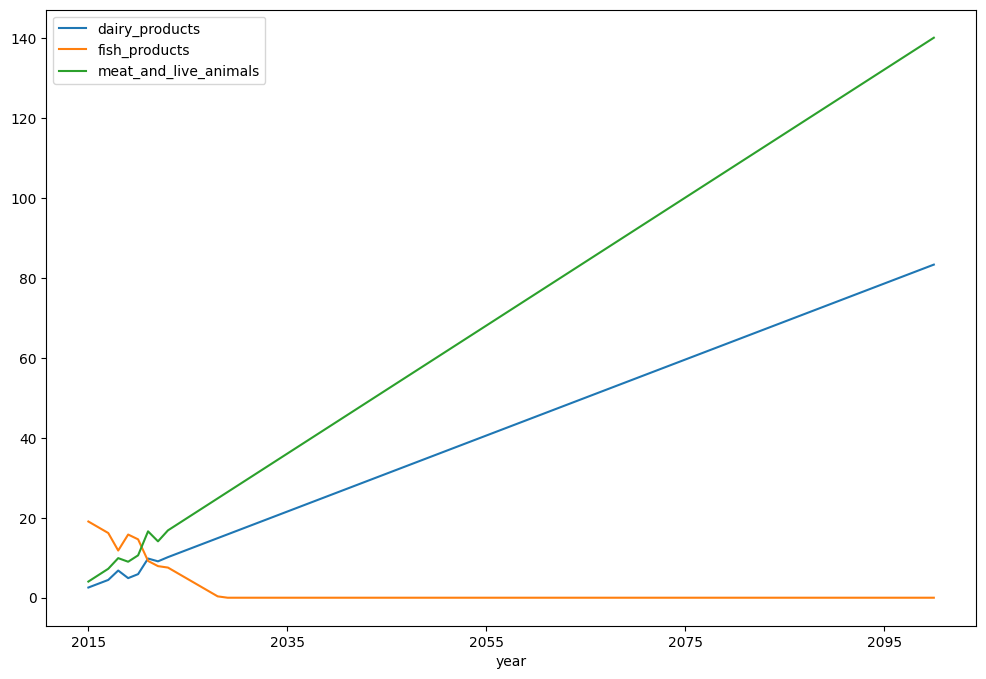

In [19]:
lvst_imports_full_df.plot(kind="line", x="year", y=lvst_imports_full_df.columns[1:], figsize=(12, 8))

### Now we need to allocate the imports to our livestock categories

In [20]:
livestock_categories = {
    "buffalo": "meat_and_live_animals",
    "cattle_dairy": "dairy_products",
    "cattle_nondairy": "meat_and_live_animals",
    "chickens": "meat_and_live_animals",
    "goats": "meat_and_live_animals",
    "horses": "meat_and_live_animals",
    "mules": "meat_and_live_animals",
    "pigs": "meat_and_live_animals",
    "sheep": "meat_and_live_animals",
}

In [21]:
pop_lvst_initial_df = uga_legacy_df[uga_legacy_df.columns[uga_legacy_df.columns.str.contains("pop_lvst_initial")]].copy()
# We will drop cattle_dairy since there is a direct match with dairy products
pop_lvst_initial_df = pop_lvst_initial_df.drop(columns=["pop_lvst_initial_cattle_dairy"])
pop_lvst_initial_df.head()

,pop_lvst_initial_chickens,pop_lvst_initial_goats,pop_lvst_initial_cattle_nondairy,pop_lvst_initial_horses,pop_lvst_initial_mules,pop_lvst_initial_sheep,pop_lvst_initial_pigs,pop_lvst_initial_buffalo
0,46039000.0,15312000.0,14031000.0,0.0,19220.0,3842000.0,3916000.0,0.0
1,46291000.0,15725000.0,14368000.0,0.0,19247.0,4198000.0,4037000.0,0.0
2,47578000.0,16034000.0,14189000.0,0.0,19277.0,4445000.0,4109000.0,0.0
3,48901000.0,16419000.0,14572000.0,0.0,19310.0,4584000.0,4245000.0,0.0
4,43121000.0,16945000.0,14785000.0,0.0,19343.0,4666000.0,4411000.0,0.0


In [22]:
shares_of_pop_lvst = pop_lvst_initial_df.div(pop_lvst_initial_df.sum(axis=1), axis=0)
shares_of_pop_lvst.head()

,pop_lvst_initial_chickens,pop_lvst_initial_goats,pop_lvst_initial_cattle_nondairy,pop_lvst_initial_horses,pop_lvst_initial_mules,pop_lvst_initial_sheep,pop_lvst_initial_pigs,pop_lvst_initial_buffalo
0,0.553625,0.184129,0.168725,0.0,0.000231,0.046201,0.047090,0.0
1,0.546928,0.185791,0.169758,0.0,0.000227,0.049599,0.047697,0.0
2,0.550835,0.185634,0.164273,0.0,0.000223,0.051462,0.047572,0.0
3,0.551057,0.185023,0.164209,0.0,0.000218,0.051656,0.047836,0.0
4,0.513667,0.201853,0.176122,0.0,0.000230,0.055582,0.052545,0.0


In [23]:
mean_shares_pop_lvst = shares_of_pop_lvst.mean()
mean_shares_pop_lvst

pop_lvst_initial_chickens           0.530717
pop_lvst_initial_goats              0.196030
pop_lvst_initial_cattle_nondairy    0.167134
pop_lvst_initial_horses             0.000000
pop_lvst_initial_mules              0.000215
pop_lvst_initial_sheep              0.054020
pop_lvst_initial_pigs               0.051885
pop_lvst_initial_buffalo            0.000000
dtype: float64

In [24]:
lvst_imports_full_df.head()

,year,dairy_products,fish_products,meat_and_live_animals
0,2015,2.55,19.06,4.04
1,2016,3.50,17.62,5.64
2,2017,4.45,16.18,7.24
3,2018,6.80,11.80,9.90
4,2019,4.90,15.80,9.00


In [25]:
# use mean shares to allocate imports to livestock categories
final_usd_imports_df = lvst_imports_full_df[["year"]].copy()
for lvst_cat, export_cat in livestock_categories.items():
    if lvst_cat == "cattle_dairy":
        final_usd_imports_df[lvst_cat + "_imports_usd"] = lvst_imports_full_df[export_cat]
    else:
        final_usd_imports_df[lvst_cat + "_imports_usd"] = lvst_imports_full_df[export_cat] * mean_shares_pop_lvst["pop_lvst_initial_" + lvst_cat]

final_usd_imports_df.head()

,year,buffalo_imports_usd,cattle_dairy_imports_usd,cattle_nondairy_imports_usd,chickens_imports_usd,goats_imports_usd,horses_imports_usd,mules_imports_usd,pigs_imports_usd,sheep_imports_usd
0,2015,0.0,2.55,0.675222,2.144095,0.791960,0.0,0.000867,0.209615,0.218241
1,2016,0.0,3.50,0.942637,2.993242,1.105608,0.0,0.001211,0.292630,0.304673
2,2017,0.0,4.45,1.210051,3.842388,1.419256,0.0,0.001554,0.375646,0.391105
3,2018,0.0,6.80,1.654628,5.254095,1.940695,0.0,0.002125,0.513659,0.534798
4,2019,0.0,4.90,1.504207,4.776450,1.764268,0.0,0.001932,0.466963,0.486180


In [26]:
final_usd_imports_df.tail()

,year,buffalo_imports_usd,cattle_dairy_imports_usd,cattle_nondairy_imports_usd,chickens_imports_usd,goats_imports_usd,horses_imports_usd,mules_imports_usd,pigs_imports_usd,sheep_imports_usd
81,2096,0.0,79.50,22.335809,70.924971,26.197419,0.0,0.028688,6.933883,7.219229
82,2097,0.0,80.45,22.603224,71.774118,26.511066,0.0,0.029032,7.016899,7.305661
83,2098,0.0,81.40,22.870638,72.623264,26.824714,0.0,0.029375,7.099915,7.392093
84,2099,0.0,82.35,23.138053,73.472411,27.138362,0.0,0.029719,7.182930,7.478525
85,2100,0.0,83.30,23.405468,74.321558,27.452009,0.0,0.030062,7.265946,7.564957


In [27]:
# Validation
is_dairy_match = np.isclose(final_usd_imports_df["cattle_dairy_imports_usd"], lvst_imports_full_df["dairy_products"]).all()
print("cattle_dairy_imports_usd matches projected dairy_products:", is_dairy_match)

meat_imports_sum = final_usd_imports_df.drop(columns=["cattle_dairy_imports_usd", "year"]).sum(axis=1)
is_meat_match = np.isclose(meat_imports_sum, lvst_imports_full_df["meat_and_live_animals"]).all()
print("Sum of allocated meat_and_live_animals matches projected:", is_meat_match)

if not is_dairy_match:
    print("First mismatches (dairy):")
    print(final_usd_imports_df["cattle_dairy_imports_usd"].sub(lvst_imports_full_df["dairy_products"]).abs().nlargest(5))

if not is_meat_match:
    print("First mismatches (meat):")
    print(meat_imports_sum.sub(lvst_imports_full_df["meat_and_live_animals"]).abs().nlargest(5))

cattle_dairy_imports_usd matches projected dairy_products: True
Sum of allocated meat_and_live_animals matches projected: True


### Then, we need to convert the USD to livestock head counts

In [28]:
# Load FAOSTAT data
fao_lvst_df = pd.read_csv(os.path.join(LVST_DATA_DIR_PATH, "FAOSTAT_imports_data_en_9-15-2025.csv"))
fao_lvst_df = fao_lvst_df.drop(columns=["Area", "Domain"])
fao_lvst_df.head()

,Element,Item,Year,Unit,Value
0,Import quantity,Cattle,2018,An,1055
1,Import value,Cattle,2018,1000 USD,443
2,Import quantity,Cattle,2019,An,657
3,Import value,Cattle,2019,1000 USD,182
4,Import quantity,Cattle,2020,An,329


In [29]:
fao_lvst_df.Item.unique()

array(['Cattle', 'Chickens', 'Goats', 'Horses', 'Sheep', 'Swine / pigs'],
      dtype=object)

In [30]:
livestock_categories.keys()

dict_keys(['buffalo', 'cattle_dairy', 'cattle_nondairy', 'chickens', 'goats', 'horses', 'mules', 'pigs', 'sheep'])

In [31]:
# Keep only the latest available year for each element-item pair
fao_lvst_df = fao_lvst_df.sort_values("Year").drop_duplicates(subset=["Element", "Item"], keep="last")
fao_lvst_df

,Element,Item,Year,Unit,Value
43,Import value,Horses,2021,1000 USD,11
42,Import quantity,Horses,2021,An,4
34,Import quantity,Goats,2023,An,994
52,Import quantity,Sheep,2023,An,199
53,Import value,Sheep,2023,1000 USD,82
64,Import quantity,Swine / pigs,2023,An,4325
23,Import value,Chickens,2023,1000 USD,14710
22,Import quantity,Chickens,2023,1000 An,5770
11,Import value,Cattle,2023,1000 USD,289
10,Import quantity,Cattle,2023,An,354


In [32]:
# Where Unit is "1000 An" multiply by 1000 to get An
fao_lvst_df.loc[fao_lvst_df["Unit"] == "1000 An", "Value"] = (
	fao_lvst_df.loc[fao_lvst_df["Unit"] == "1000 An", "Value"] * 1000
)
fao_lvst_df

,Element,Item,Year,Unit,Value
43,Import value,Horses,2021,1000 USD,11
42,Import quantity,Horses,2021,An,4
34,Import quantity,Goats,2023,An,994
52,Import quantity,Sheep,2023,An,199
53,Import value,Sheep,2023,1000 USD,82
64,Import quantity,Swine / pigs,2023,An,4325
23,Import value,Chickens,2023,1000 USD,14710
22,Import quantity,Chickens,2023,1000 An,5770000
11,Import value,Cattle,2023,1000 USD,289
10,Import quantity,Cattle,2023,An,354


In [33]:
# We drop unnesessary columns
fao_lvst_df = fao_lvst_df.drop(columns=["Year", "Unit"])
fao_lvst_df.head()

,Element,Item,Value
43,Import value,Horses,11
42,Import quantity,Horses,4
34,Import quantity,Goats,994
52,Import quantity,Sheep,199
53,Import value,Sheep,82


In [34]:
# Add correct livestock category names
fao_to_ssp_lvst = [
    {"fao": "Cattle", "ssp": "cattle_nondairy"},
    {"fao": "Chickens", "ssp": "chickens"},
    {"fao": "Goats", "ssp": "goats"},
    {"fao": "Sheep", "ssp": "sheep"},
    {"fao": "Swine / pigs", "ssp": "pigs"},
    {"fao": "Horses", "ssp": "horses"}
]

fao_to_ssp_lvst_df = pd.DataFrame(fao_to_ssp_lvst)
fao_to_ssp_lvst_df

,fao,ssp
0,Cattle,cattle_nondairy
1,Chickens,chickens
2,Goats,goats
3,Sheep,sheep
4,Swine / pigs,pigs
5,Horses,horses


In [35]:
# Merge with FAO data
fao_lvst_merged_df = fao_lvst_df.merge(fao_to_ssp_lvst_df, left_on="Item", right_on="fao", how="left").drop(columns=["fao", "Item"])
fao_lvst_merged_df.head()

,Element,Value,ssp
0,Import value,11,horses
1,Import quantity,4,horses
2,Import quantity,994,goats
3,Import quantity,199,sheep
4,Import value,82,sheep


In [36]:
# pivot to have Element as columns
fao_lvst_pivot_df = fao_lvst_merged_df.pivot(index="ssp", columns="Element", values="Value").reset_index()
fao_lvst_pivot_df.columns.name = None
fao_lvst_pivot_df.head()

,ssp,Import quantity,Import value
0,cattle_nondairy,354,289
1,chickens,5770000,14710
2,goats,994,211
3,horses,4,11
4,pigs,4325,278


In [37]:
fao_lvst_pivot_df["conversion_factor_usd_per_head"] = fao_lvst_pivot_df["Import quantity"] / fao_lvst_pivot_df["Import value"]
fao_lvst_pivot_df = fao_lvst_pivot_df.rename(columns={"ssp": "lvst_category"})
fao_lvst_pivot_df.head()

,lvst_category,Import quantity,Import value,conversion_factor_usd_per_head
0,cattle_nondairy,354,289,1.224913
1,chickens,5770000,14710,392.250170
2,goats,994,211,4.710900
3,horses,4,11,0.363636
4,pigs,4325,278,15.557554


In [38]:
# Add missing livestock catetgories
remaining_lvst_cats_dict ={
    "lvst_category": ["cattle_dairy", "buffalo", "mules"],
    "Import quantity": [np.nan, np.nan, np.nan],
    "Import value": [np.nan, np.nan, np.nan],
    "conversion_factor_usd_per_head": [1.224913, 0, 0]
}

remaining_lvst_cats_df = pd.DataFrame(remaining_lvst_cats_dict)
remaining_lvst_cats_df

,lvst_category,Import quantity,Import value,conversion_factor_usd_per_head
0,cattle_dairy,NaN,NaN,1.224913
1,buffalo,NaN,NaN,0.000000
2,mules,NaN,NaN,0.000000


In [39]:
# concat with fao data
final_fao_lvst_df = pd.concat([fao_lvst_pivot_df, remaining_lvst_cats_df], ignore_index=True)
final_fao_lvst_df

,lvst_category,Import quantity,Import value,conversion_factor_usd_per_head
0,cattle_nondairy,354.0,289.0,1.224913
1,chickens,5770000.0,14710.0,392.250170
2,goats,994.0,211.0,4.710900
3,horses,4.0,11.0,0.363636
4,pigs,4325.0,278.0,15.557554
5,sheep,199.0,82.0,2.426829
6,cattle_dairy,NaN,NaN,1.224913
7,buffalo,NaN,NaN,0.000000
8,mules,NaN,NaN,0.000000


In [40]:
final_fao_lvst_df = final_fao_lvst_df.set_index("lvst_category")
final_fao_lvst_df

,Import quantity,Import value,conversion_factor_usd_per_head
lvst_category,,,
cattle_nondairy,354.0,289.0,1.224913
chickens,5770000.0,14710.0,392.250170
goats,994.0,211.0,4.710900
horses,4.0,11.0,0.363636
pigs,4325.0,278.0,15.557554
sheep,199.0,82.0,2.426829
cattle_dairy,NaN,NaN,1.224913
buffalo,NaN,NaN,0.000000
mules,NaN,NaN,0.000000


In [41]:
final_usd_imports_df.head()

,year,buffalo_imports_usd,cattle_dairy_imports_usd,cattle_nondairy_imports_usd,chickens_imports_usd,goats_imports_usd,horses_imports_usd,mules_imports_usd,pigs_imports_usd,sheep_imports_usd
0,2015,0.0,2.55,0.675222,2.144095,0.791960,0.0,0.000867,0.209615,0.218241
1,2016,0.0,3.50,0.942637,2.993242,1.105608,0.0,0.001211,0.292630,0.304673
2,2017,0.0,4.45,1.210051,3.842388,1.419256,0.0,0.001554,0.375646,0.391105
3,2018,0.0,6.80,1.654628,5.254095,1.940695,0.0,0.002125,0.513659,0.534798
4,2019,0.0,4.90,1.504207,4.776450,1.764268,0.0,0.001932,0.466963,0.486180


In [42]:
final_headcount_imports_df = pd.DataFrame()
for lvst_cat in livestock_categories.keys():
    # Get the series from usd imports
    usd_series = final_usd_imports_df[lvst_cat + "_imports_usd"]
    # Get the conversion factor from final_fao_lvst_df
    conv_factor = final_fao_lvst_df.loc[lvst_cat, "conversion_factor_usd_per_head"]
    # Calculate headcount series
    final_headcount_imports_df["imports_lvst_" + lvst_cat] = usd_series * conv_factor


# Add year column
final_headcount_imports_df["year"] = final_usd_imports_df["year"]
final_headcount_imports_df.head()

,imports_lvst_buffalo,imports_lvst_cattle_dairy,imports_lvst_cattle_nondairy,imports_lvst_chickens,imports_lvst_goats,imports_lvst_horses,imports_lvst_mules,imports_lvst_pigs,imports_lvst_sheep,year
0,0.0,3.123528,0.827089,841.021711,3.730846,0.0,0.0,3.261090,0.529633,2015
1,0.0,4.287195,1.154648,1174.099616,5.208409,0.0,0.0,4.552610,0.739389,2016
2,0.0,5.450863,1.482208,1507.177521,6.685972,0.0,0.0,5.844131,0.949144,2017
3,0.0,8.329408,2.026776,2060.919538,9.142420,0.0,0.0,7.991284,1.297863,2018
4,0.0,6.002074,1.842524,1873.563217,8.311291,0.0,0.0,7.264804,1.179875,2019


### Quick Validation

<Axes: xlabel='year'>

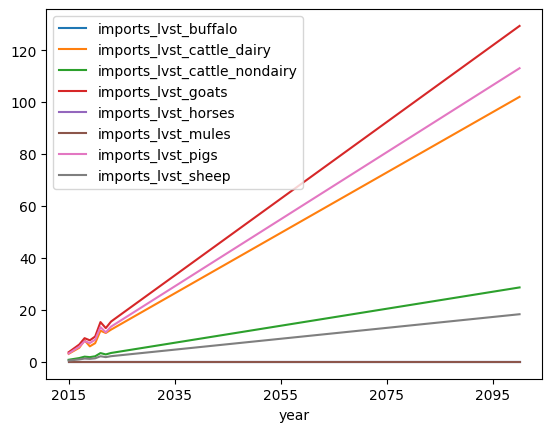

In [43]:
final_headcount_imports_df.plot(kind="line", x="year", y=final_headcount_imports_df.drop(columns=["year", "imports_lvst_chickens"]).columns)

In [44]:
# Create again pop_lvst_initial_df so we include cattle_dairy
pop_lvst_initial_df = uga_legacy_df[uga_legacy_df.columns[uga_legacy_df.columns.str.contains("pop_lvst_initial")]].copy()
pop_lvst_initial_df.head()

,pop_lvst_initial_chickens,pop_lvst_initial_goats,pop_lvst_initial_cattle_nondairy,pop_lvst_initial_horses,pop_lvst_initial_mules,pop_lvst_initial_cattle_dairy,pop_lvst_initial_sheep,pop_lvst_initial_pigs,pop_lvst_initial_buffalo
0,46039000.0,15312000.0,14031000.0,0.0,19220.0,14031000.0,3842000.0,3916000.0,0.0
1,46291000.0,15725000.0,14368000.0,0.0,19247.0,14368000.0,4198000.0,4037000.0,0.0
2,47578000.0,16034000.0,14189000.0,0.0,19277.0,14189000.0,4445000.0,4109000.0,0.0
3,48901000.0,16419000.0,14572000.0,0.0,19310.0,14572000.0,4584000.0,4245000.0,0.0
4,43121000.0,16945000.0,14785000.0,0.0,19343.0,14785000.0,4666000.0,4411000.0,0.0


In [45]:
for lvst_cat in livestock_categories.keys():
    import_headcount = final_headcount_imports_df["imports_lvst_" + lvst_cat]
    initial_pop = pop_lvst_initial_df["pop_lvst_initial_" + lvst_cat][:len(import_headcount)].reset_index(drop=True)
    exceeded = import_headcount > initial_pop
    for year, is_exceeded in zip(final_headcount_imports_df["year"], exceeded):
        if is_exceeded:
            print(f"Warning: Imports for {lvst_cat} exceed initial population in year {year}.")

### Calculate the share of imported livestock
f = I/(P - E + I)


E = exports
I = imports
P = production
f  = import fraction

In [46]:
# Load exports data
lvst_exports_df = pd.read_csv(os.path.join(OUTPUT_DATA_DIR_PATH, "exports_lvst.csv"))
lvst_exports_df.head()

,year,exports_lvst_buffalo,exports_lvst_cattle_dairy,exports_lvst_cattle_nondairy,exports_lvst_chickens,exports_lvst_goats,exports_lvst_horses,exports_lvst_mules,exports_lvst_pigs,exports_lvst_sheep
0,2015,0.0,119019.769730,2273.287808,2.447784e+06,56479.409611,0.0,0.892089,8398.406589,11770.110457
1,2016,0.0,120009.010562,2292.182393,2.468129e+06,56948.842028,0.0,0.899503,8468.210511,11867.938523
2,2017,0.0,121006.473536,2311.234021,2.488643e+06,57422.176164,0.0,0.906980,8538.594613,11966.579693
3,2018,0.0,122012.226990,2330.443998,2.509327e+06,57899.444448,0.0,0.914518,8609.563717,12066.040726
4,2019,0.0,123026.339832,2349.813640,2.530184e+06,58380.679580,0.0,0.922119,8681.122686,12166.328436


In [47]:
frac_lvst_imports_df = pd.DataFrame()
for lvst_cat in livestock_categories.keys():
    exports = lvst_exports_df["exports_lvst_" + lvst_cat]
    imports = final_headcount_imports_df["imports_lvst_" + lvst_cat]
    production = pop_lvst_initial_df["pop_lvst_initial_" + lvst_cat][:len(exports)].reset_index(drop=True)
    
    # Check that exports, imports and production are not empty
    if exports.isnull().all():
        print(f"Warning: Exports for {lvst_cat} are all NaN.")
    if imports.isnull().all():
        print(f"Warning: Imports for {lvst_cat} are all NaN.")
    if production.isnull().all():
        print(f"Warning: Production for {lvst_cat} are all NaN.")

    frac_lvst_imports_df["frac_lvst_livestock_demand_imported_" + lvst_cat] = imports / (production - exports + imports)

frac_lvst_imports_df.head()

,frac_lvst_livestock_demand_imported_buffalo,frac_lvst_livestock_demand_imported_cattle_dairy,frac_lvst_livestock_demand_imported_cattle_nondairy,frac_lvst_livestock_demand_imported_chickens,frac_lvst_livestock_demand_imported_goats,frac_lvst_livestock_demand_imported_horses,frac_lvst_livestock_demand_imported_mules,frac_lvst_livestock_demand_imported_pigs,frac_lvst_livestock_demand_imported_sheep
0,NaN,2.245207e-07,5.895678e-08,0.000019,2.445571e-07,NaN,0.0,8.345495e-07,1.382770e-07
1,NaN,3.008982e-07,8.037531e-08,0.000027,3.324221e-07,NaN,0.0,1.130090e-06,1.766281e-07
2,NaN,3.874654e-07,1.044788e-07,0.000033,4.184857e-07,NaN,0.0,1.425235e-06,2.141071e-07
3,NaN,5.764298e-07,1.391093e-07,0.000044,5.587897e-07,NaN,0.0,1.886339e-06,2.838760e-07
4,NaN,4.093631e-07,1.246410e-07,0.000046,4.921818e-07,NaN,0.0,1.650219e-06,2.535275e-07


In [48]:
# fill nas with 0
frac_lvst_imports_df = frac_lvst_imports_df.fillna(0)
frac_lvst_imports_df.isna().sum()

frac_lvst_livestock_demand_imported_buffalo            0
frac_lvst_livestock_demand_imported_cattle_dairy       0
frac_lvst_livestock_demand_imported_cattle_nondairy    0
frac_lvst_livestock_demand_imported_chickens           0
frac_lvst_livestock_demand_imported_goats              0
frac_lvst_livestock_demand_imported_horses             0
frac_lvst_livestock_demand_imported_mules              0
frac_lvst_livestock_demand_imported_pigs               0
frac_lvst_livestock_demand_imported_sheep              0
dtype: int64

## Validation

In [49]:
# Check if any of the values in the columns i s greater than 1
for col in frac_lvst_imports_df.columns:
    if (frac_lvst_imports_df[col] > 1).any():
        print(f"Warning: Some values in {col} are greater than 1.")

In [50]:
legacy_frac_lvst_imports_df = uga_legacy_df[[col for col in uga_legacy_df.columns if "frac_lvst_livestock_demand_imported_" in col]]

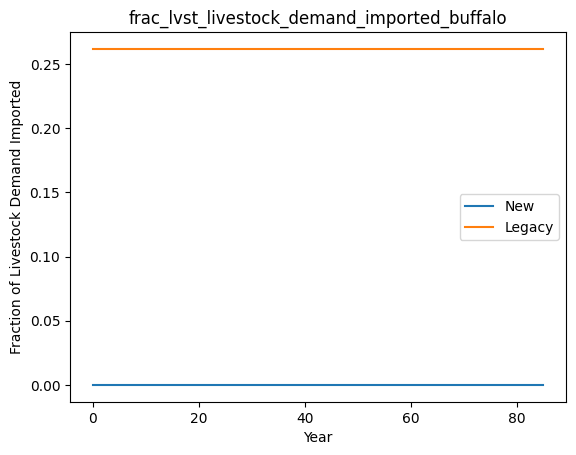

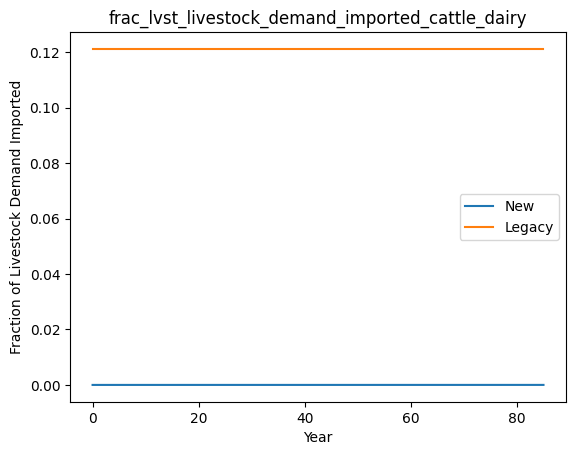

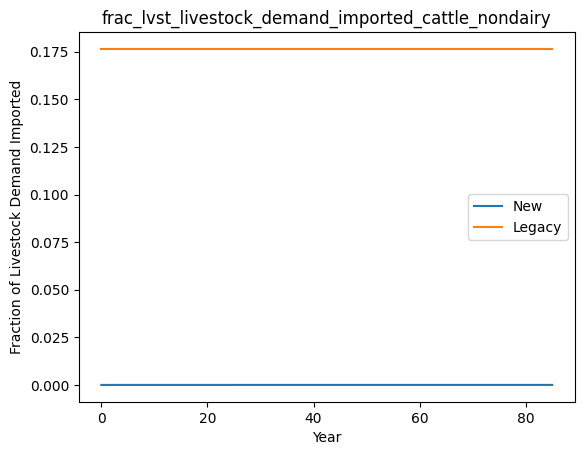

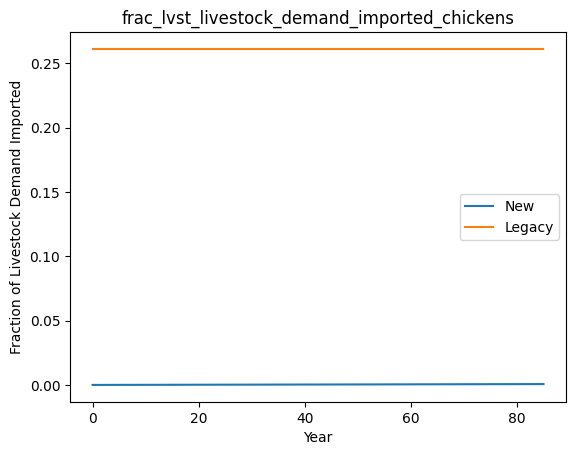

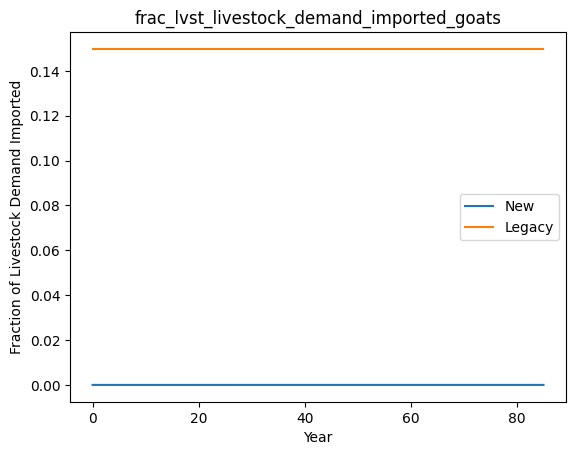

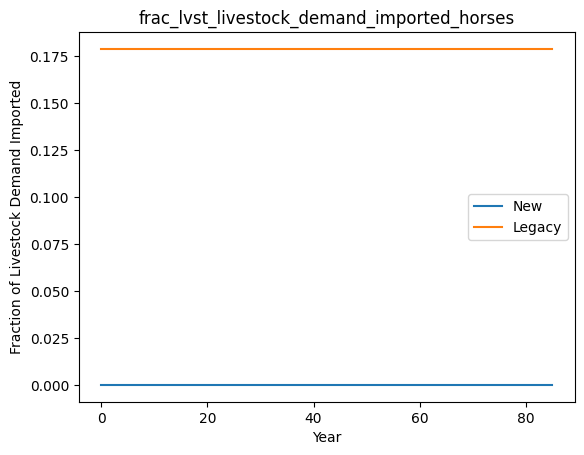

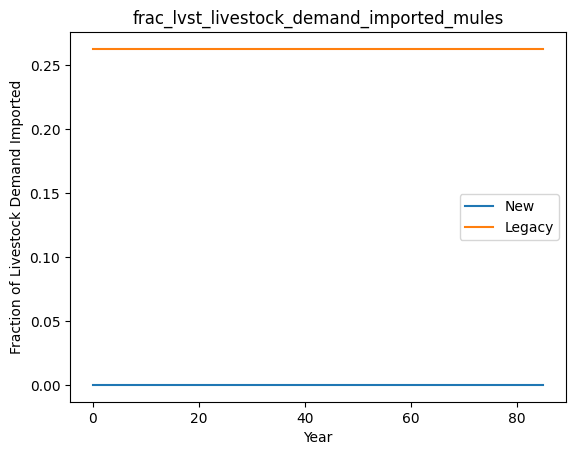

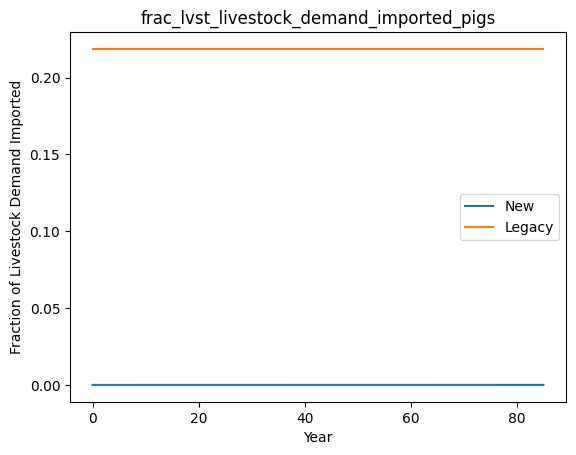

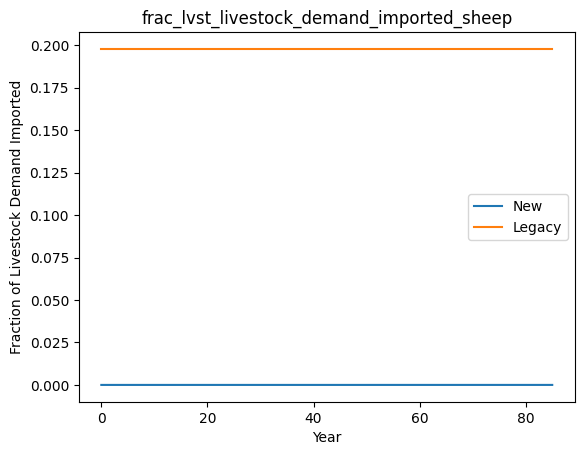

In [51]:
for col in frac_lvst_imports_df.columns:

    plt.plot(frac_lvst_imports_df[col])
    plt.plot(legacy_frac_lvst_imports_df[col])
    plt.legend(("New", "Legacy"))
    plt.title(col)
    plt.xlabel("Year")
    plt.ylabel("Fraction of Livestock Demand Imported")
    plt.show()

In [52]:
# Add year column
frac_lvst_imports_df["year"] = final_usd_imports_df["year"]
frac_lvst_imports_df = frac_lvst_imports_df[["year"] + [col for col in frac_lvst_imports_df.columns if col != "year"]]
frac_lvst_imports_df.head()

,year,frac_lvst_livestock_demand_imported_buffalo,frac_lvst_livestock_demand_imported_cattle_dairy,frac_lvst_livestock_demand_imported_cattle_nondairy,frac_lvst_livestock_demand_imported_chickens,frac_lvst_livestock_demand_imported_goats,frac_lvst_livestock_demand_imported_horses,frac_lvst_livestock_demand_imported_mules,frac_lvst_livestock_demand_imported_pigs,frac_lvst_livestock_demand_imported_sheep
0,2015,0.0,2.245207e-07,5.895678e-08,0.000019,2.445571e-07,0.0,0.0,8.345495e-07,1.382770e-07
1,2016,0.0,3.008982e-07,8.037531e-08,0.000027,3.324221e-07,0.0,0.0,1.130090e-06,1.766281e-07
2,2017,0.0,3.874654e-07,1.044788e-07,0.000033,4.184857e-07,0.0,0.0,1.425235e-06,2.141071e-07
3,2018,0.0,5.764298e-07,1.391093e-07,0.000044,5.587897e-07,0.0,0.0,1.886339e-06,2.838760e-07
4,2019,0.0,4.093631e-07,1.246410e-07,0.000046,4.921818e-07,0.0,0.0,1.650219e-06,2.535275e-07


In [53]:
frac_lvst_imports_df.tail()

,year,frac_lvst_livestock_demand_imported_buffalo,frac_lvst_livestock_demand_imported_cattle_dairy,frac_lvst_livestock_demand_imported_cattle_nondairy,frac_lvst_livestock_demand_imported_chickens,frac_lvst_livestock_demand_imported_goats,frac_lvst_livestock_demand_imported_horses,frac_lvst_livestock_demand_imported_mules,frac_lvst_livestock_demand_imported_pigs,frac_lvst_livestock_demand_imported_sheep
81,2096,0.0,0.000007,0.000002,0.000643,0.000007,0.0,0.0,0.000023,0.000004
82,2097,0.0,0.000007,0.000002,0.000651,0.000007,0.0,0.0,0.000023,0.000004
83,2098,0.0,0.000007,0.000002,0.000659,0.000007,0.0,0.0,0.000023,0.000004
84,2099,0.0,0.000007,0.000002,0.000668,0.000007,0.0,0.0,0.000024,0.000004
85,2100,0.0,0.000007,0.000002,0.000676,0.000007,0.0,0.0,0.000024,0.000004


In [54]:
# Save to csv
frac_lvst_imports_df.to_csv(os.path.join(OUTPUT_DATA_DIR_PATH, "frac_lvst_livestock_demand_imported.csv"), index=False)
